In [1]:
import pandas as pd

df = pd.read_csv('/content/Experience-Salary.csv')
display(df.head())

,exp(in months),salary(in thousands)
0,18.290293,16.521825
1,17.023407,11.666234
2,26.343613,23.167255
3,19.105834,20.877145
4,27.742516,23.166236


## Exploratory Data Analysis (EDA)

In [2]:
# Display basic information about the DataFrame
print("DataFrame Info:")
df.info()

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   exp(in months)        1000 non-null   float64
 1   salary(in thousands)  1000 non-null   float64
dtypes: float64(2)
memory usage: 15.8 KB


In [3]:
# Display descriptive statistics
print("\nDescriptive Statistics:")
display(df.describe())


Descriptive Statistics:


,exp(in months),salary(in thousands)
count,1000.000000,1000.000000
mean,26.157825,26.722597
std,8.717091,8.844761
min,0.697594,-1.276342
25%,20.073600,20.531008
50%,25.875225,26.745576
75%,32.406986,32.615753
max,49.463222,55.297016


In [4]:
# Check for missing values
print("\nMissing Values:")
display(df.isnull().sum())


Missing Values:


,0
exp(in months),0
salary(in thousands),0


### Visualizing Distributions

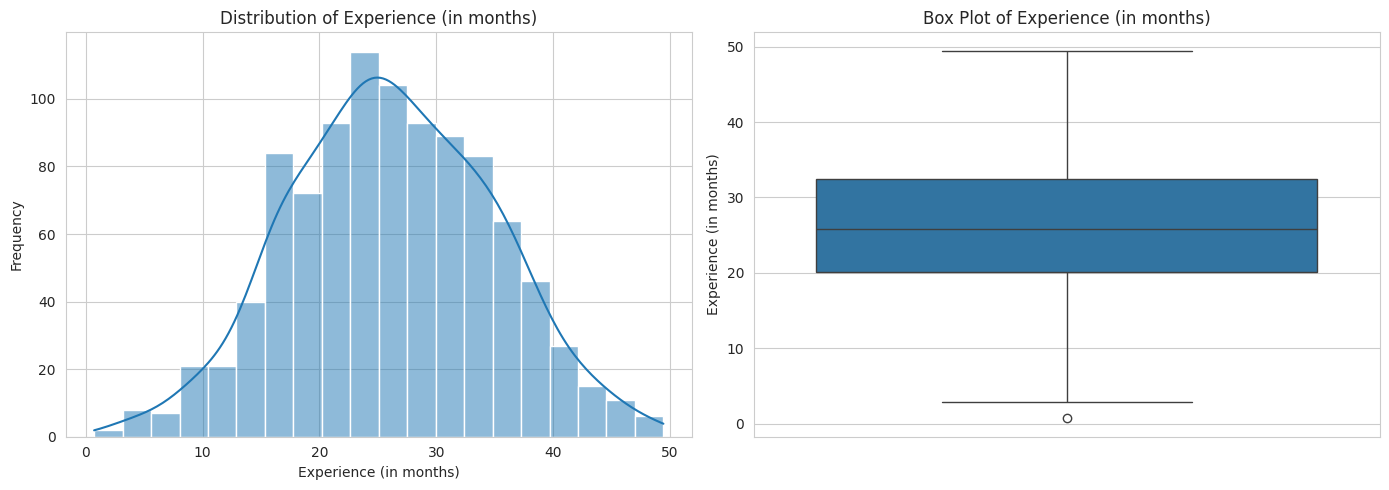

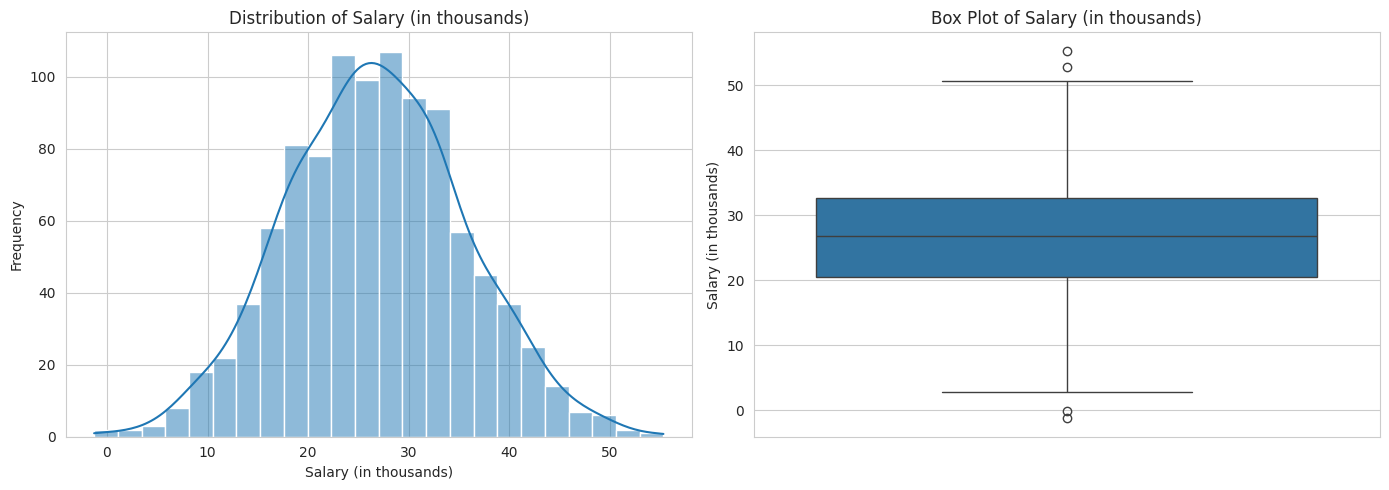

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for the plots
sns.set_style("whitegrid")

# Create subplots for 'exp(in months)'
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['exp(in months)'], kde=True, ax=axes[0])
axes[0].set_title('Distribution of Experience (in months)')
axes[0].set_xlabel('Experience (in months)')
axes[0].set_ylabel('Frequency')

sns.boxplot(y=df['exp(in months)'], ax=axes[1])
axes[1].set_title('Box Plot of Experience (in months)')
axes[1].set_ylabel('Experience (in months)')

plt.tight_layout()
plt.show()

# Create subplots for 'salary(in thousands)'
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['salary(in thousands)'], kde=True, ax=axes[0])
axes[0].set_title('Distribution of Salary (in thousands)')
axes[0].set_xlabel('Salary (in thousands)')
axes[0].set_ylabel('Frequency')

sns.boxplot(y=df['salary(in thousands)'], ax=axes[1])
axes[1].set_title('Box Plot of Salary (in thousands)')
axes[1].set_ylabel('Salary (in thousands)')

plt.tight_layout()
plt.show()

### Relationship between Experience and Salary

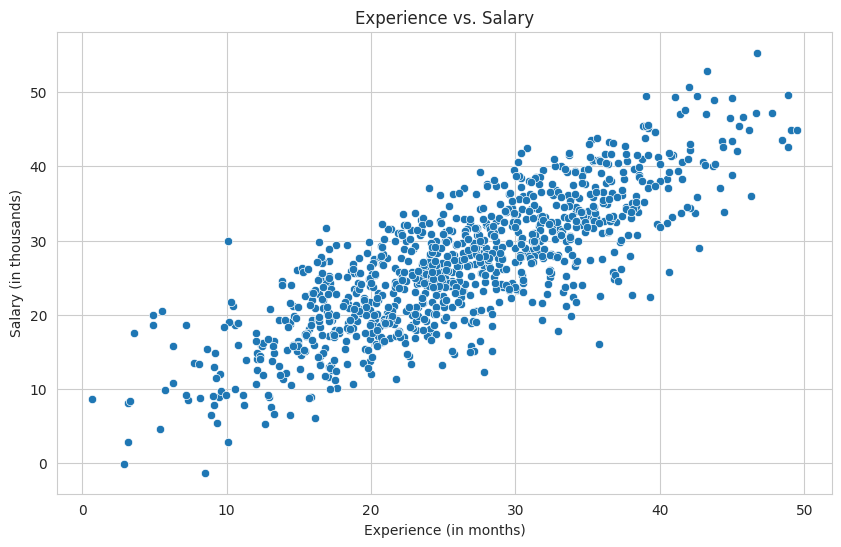

In [6]:
# Create a scatter plot to show the relationship between experience and salary
plt.figure(figsize=(10, 6))
sns.scatterplot(x='exp(in months)', y='salary(in thousands)', data=df)
plt.title('Experience vs. Salary')
plt.xlabel('Experience (in months)')
plt.ylabel('Salary (in thousands)')
plt.show()

## Linear Regression Analysis

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Define features (X) and target (y)
X = df[['exp(in months)']]
y = df['salary(in thousands)']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Training set size: 800 samples
Testing set size: 200 samples


### Model Training

In [8]:
# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Print the coefficients
print(f"Coefficient (slope): {model.coef_[0]:.2f}")
print(f"Intercept: {model.intercept_:.2f}")

Coefficient (slope): 0.83
Intercept: 4.91


### Model Evaluation

In [9]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

Mean Absolute Error (MAE): 4.16
Mean Squared Error (MSE): 27.65
Root Mean Squared Error (RMSE): 5.26
R-squared (R2): 0.62


### Visualizing the Regression Line

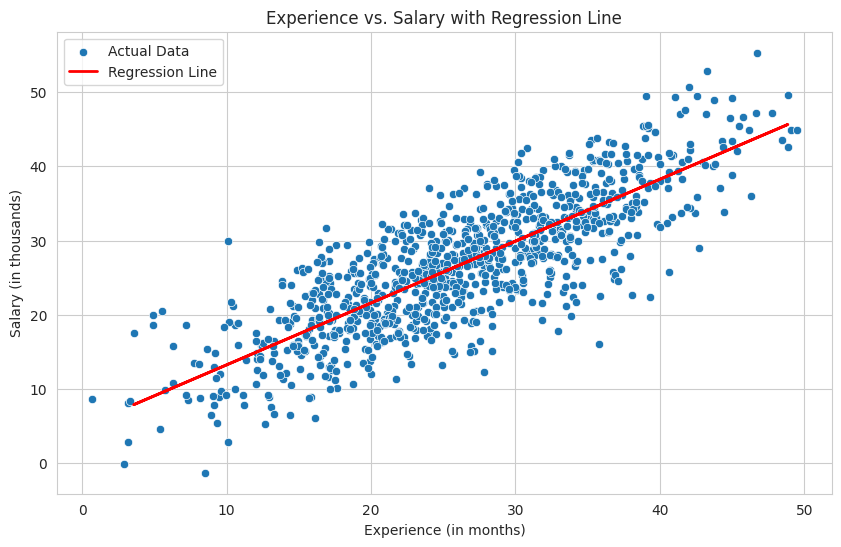

In [10]:
# Plot the regression line
plt.figure(figsize=(10, 6))
sns.scatterplot(x='exp(in months)', y='salary(in thousands)', data=df, label='Actual Data')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regression Line')
plt.title('Experience vs. Salary with Regression Line')
plt.xlabel('Experience (in months)')
plt.ylabel('Salary (in thousands)')
plt.legend()
plt.show()

### Error Analysis

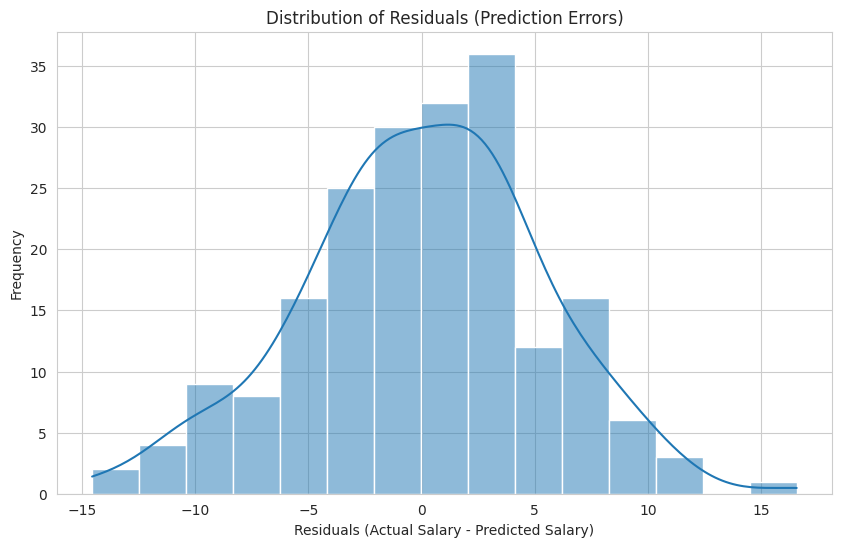

Mean Absolute Error (MAE): 4.16


In [11]:
# Calculate residuals (errors)
residuals = y_test - y_pred

# Plot histogram of residuals
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True)
plt.title('Distribution of Residuals (Prediction Errors)')
plt.xlabel('Residuals (Actual Salary - Predicted Salary)')
plt.ylabel('Frequency')
plt.show()

print(f"Mean Absolute Error (MAE): {mae:.2f}")

In [12]:
# Calculate Mean Absolute Percentage Error (MAPE)
# Avoid division by zero for actual values close to zero
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

Mean Absolute Percentage Error (MAPE): 18.82%
